In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [2]:
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\Car details v3.csv")

### DATA CLEANING


In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
df.shape

(8128, 13)

In [5]:
df = df.drop(columns=['torque'])

In [6]:
df.shape

(8128, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(8)
memory usage: 762.1+ KB


In [8]:
df.isnull().mean()

name             0.000000
year             0.000000
selling_price    0.000000
km_driven        0.000000
fuel             0.000000
seller_type      0.000000
transmission     0.000000
owner            0.000000
mileage          0.027190
engine           0.027190
max_power        0.026452
seats            0.027190
dtype: float64

In [9]:
df = df.dropna(subset=['mileage', 'engine','max_power','seats']) ## null values ko drop kr diya hai 

In [10]:
df['mileage_value'] = df['mileage'].str.extract(r'(\d+\.?\d*)')[0].astype(float) ## mileage ko sahi kiya hai units alag and value alag
df['mileage_unit'] = df['mileage'].str.extract(r'(kmpl|km/kg)')[0]

In [11]:
df['engine_value'] = df['engine'].str.extract(r'(\d+\.?\d*)')[0].astype(float) ## engine se unit alag kr di

In [12]:
df['max_power_value'] = df['max_power'].str.extract(r'(\d+\.?\d*)')[0].astype(float) ## max_power se unit alag kr di

In [13]:
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,mileage_value,mileage_unit,engine_value,max_power_value
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0,23.40,kmpl,1248.0,74.00
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0,21.14,kmpl,1498.0,103.52
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5.0,17.70,kmpl,1497.0,78.00
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5.0,23.00,kmpl,1396.0,90.00
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5.0,16.10,kmpl,1298.0,88.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,5.0,18.50,kmpl,1197.0,82.85
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,5.0,16.80,kmpl,1493.0,110.00
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,5.0,19.30,kmpl,1248.0,73.90
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,5.0,23.57,kmpl,1396.0,70.00


In [14]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage            0
engine             0
max_power          0
seats              0
mileage_value      0
mileage_unit       0
engine_value       0
max_power_value    1
dtype: int64

In [15]:
df = df.dropna(subset=['max_power_value']) 

In [16]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage            0
engine             0
max_power          0
seats              0
mileage_value      0
mileage_unit       0
engine_value       0
max_power_value    0
dtype: int64

In [17]:
df.shape

(7906, 16)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7906 entries, 0 to 8127
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             7906 non-null   object 
 1   year             7906 non-null   int64  
 2   selling_price    7906 non-null   int64  
 3   km_driven        7906 non-null   int64  
 4   fuel             7906 non-null   object 
 5   seller_type      7906 non-null   object 
 6   transmission     7906 non-null   object 
 7   owner            7906 non-null   object 
 8   mileage          7906 non-null   object 
 9   engine           7906 non-null   object 
 10  max_power        7906 non-null   object 
 11  seats            7906 non-null   float64
 12  mileage_value    7906 non-null   float64
 13  mileage_unit     7906 non-null   object 
 14  engine_value     7906 non-null   float64
 15  max_power_value  7906 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 1.0+ MB


## EDA(Exploratory Data Analysis)

<Axes: xlabel='selling_price', ylabel='Count'>

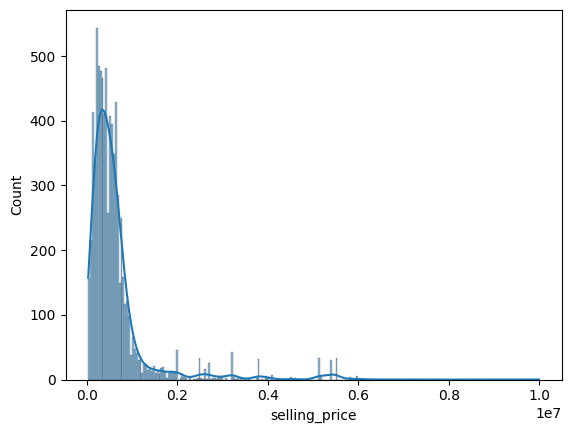

In [19]:
## distribution of selling_price
sns.histplot(data=df, x='selling_price', kde=True)

Higher-priced cars generally have lower/less driven kilometers, while lower-priced cars show a wider range of km driven.


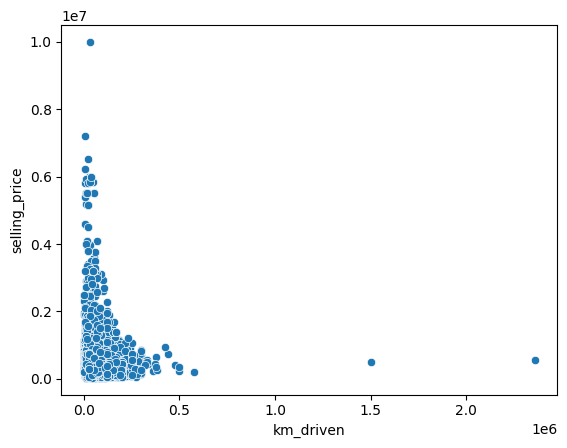

In [20]:
## relation of selling price and km_driven
sns.scatterplot(data=df,x='km_driven',y='selling_price')
print("Higher-priced cars generally have lower/less driven kilometers, while lower-priced cars show a wider range of km driven.")

Most cars have a mileage between approximately 10 and 30, irrespective of their selling price. The scatter plot does not show a strong linear relationship between mileage and selling price.


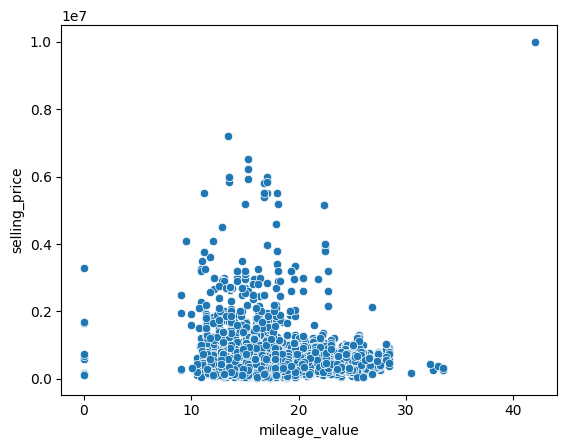

In [21]:
## relation of selling price and mileage
sns.scatterplot(data=df,x='mileage_value',y='selling_price')
print('Most cars have a mileage between approximately 10 and 30, irrespective of their selling price. The scatter plot does not show a strong linear relationship between mileage and selling price.')

Engine capacity does not show a strong linear relationship with selling price, although higher-priced cars are also present among vehicles with larger engine capacities.


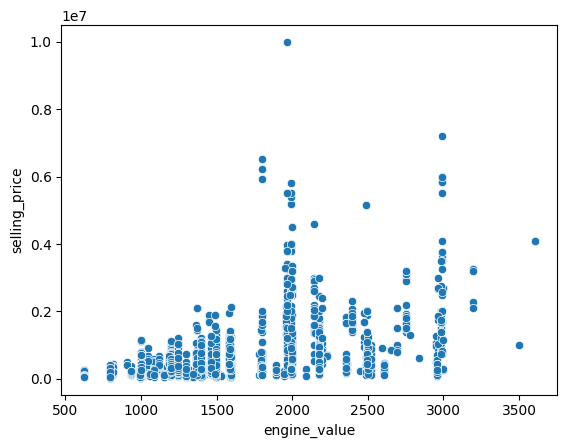

In [22]:
## relation of selling price and engine
sns.scatterplot(data=df,x='engine_value',y='selling_price')
print("Engine capacity does not show a strong linear relationship with selling price, although higher-priced cars are also present among vehicles with larger engine capacities.")

Max power shows a positive relationship with selling price. Generally, cars with higher maximum power tend to have higher selling prices, although the relationship is not very strong.


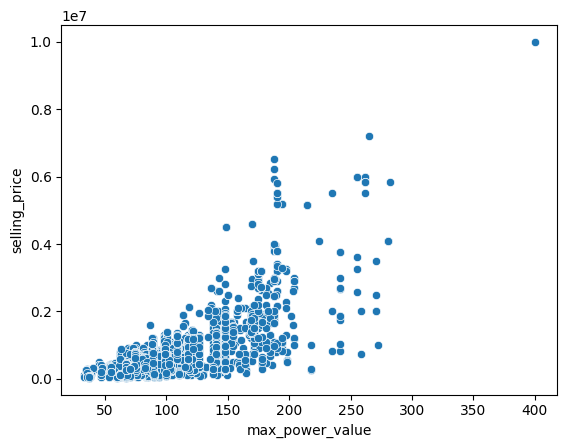

In [23]:
## relation of selling price and power
sns.scatterplot(data=df,x='max_power_value',y='selling_price') 
print("Max power shows a positive relationship with selling price. Generally, cars with higher maximum power tend to have higher selling prices, although the relationship is not very strong.")

year by year selling price increases


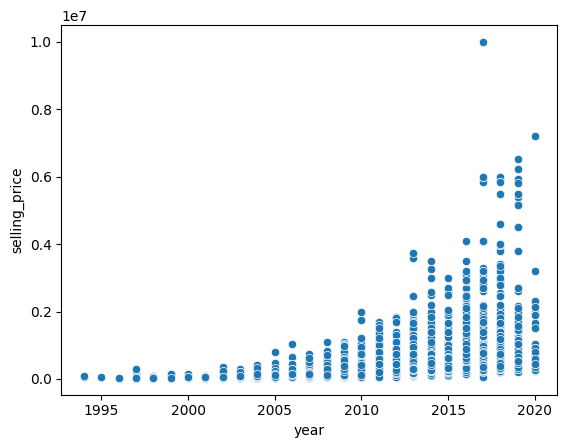

In [24]:
## relation of selling price and year
sns.scatterplot(data=df,x='year',y='selling_price') 
print("year by year selling price increases")

Diesel cars have the highest average selling price


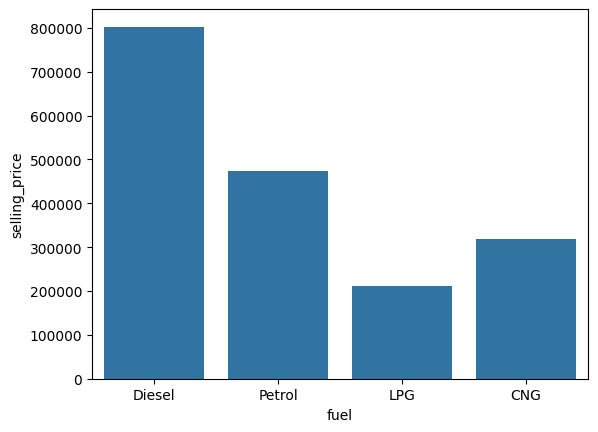

In [25]:
### relation between fuel and selling_price
sns.barplot(data=df,x='fuel',y='selling_price',errorbar=None)
print("Diesel cars have the highest average selling price")

Dealer-sold cars have the highest average selling price, while individually sold cars have the lowest average selling price in this dataset


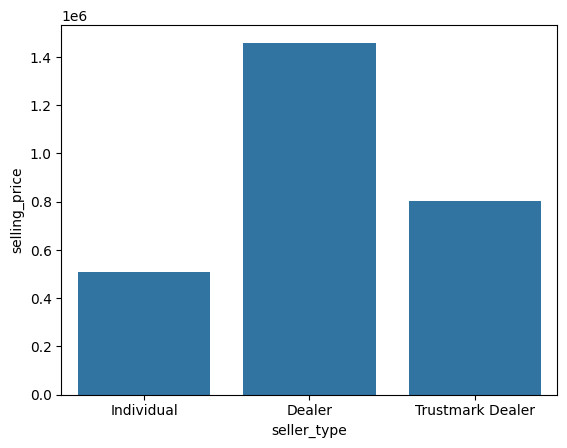

In [26]:
### relation between seller_type and selling_price
sns.barplot(data=df,x='seller_type',y='selling_price',errorbar=None)
print("Dealer-sold cars have the highest average selling price, while individually sold cars have the lowest average selling price in this dataset")

([0, 1, 2, 3, 4],
 [Text(0, 0, 'First Owner'),
  Text(1, 0, 'Second Owner'),
  Text(2, 0, 'Third Owner'),
  Text(3, 0, 'Fourth & Above Owner'),
  Text(4, 0, 'Test Drive Car')])

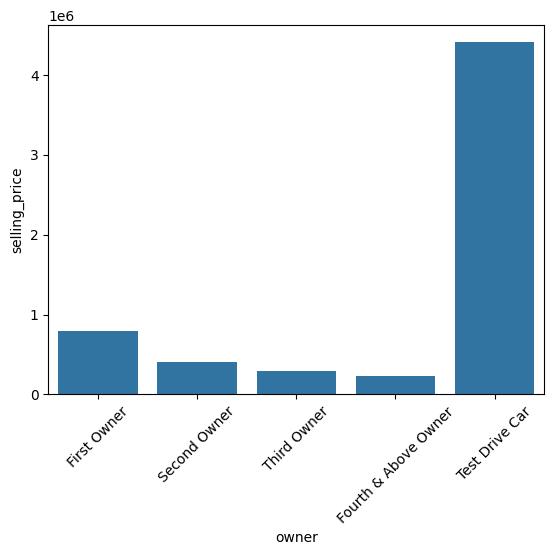

In [27]:
### relation between owner_type and selling_price
sns.barplot(data=df,x='owner',y='selling_price',errorbar=None,)
plt.xticks(rotation=45)

Automatic car's Average price high as compare to manual


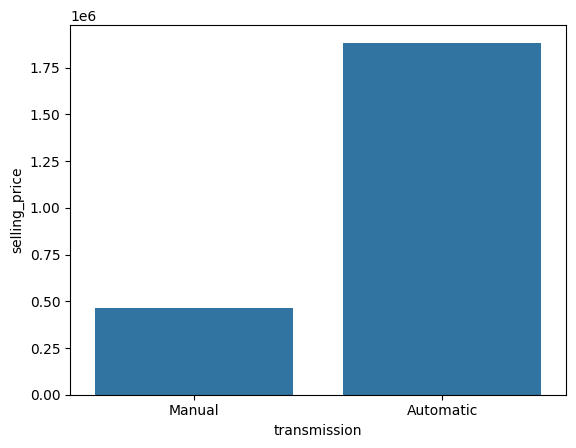

In [28]:
### relation between transmission and selling_price
sns.barplot(data=df,x='transmission',y='selling_price',errorbar=None)
print("Automatic car's Average price high as compare to manual")

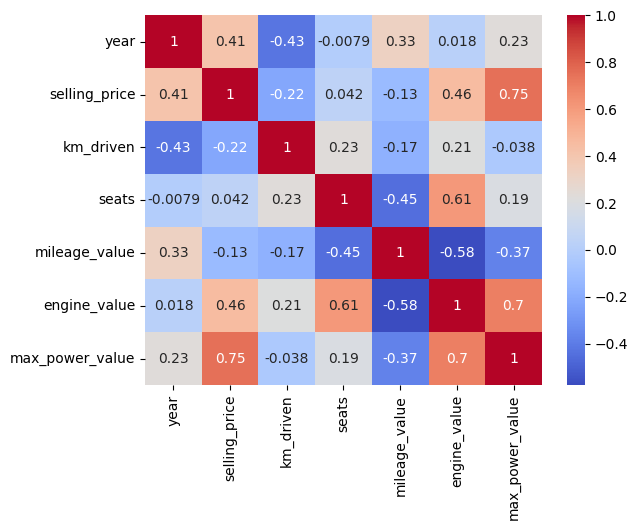

In [29]:
## relationship b/w all numerical columns
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

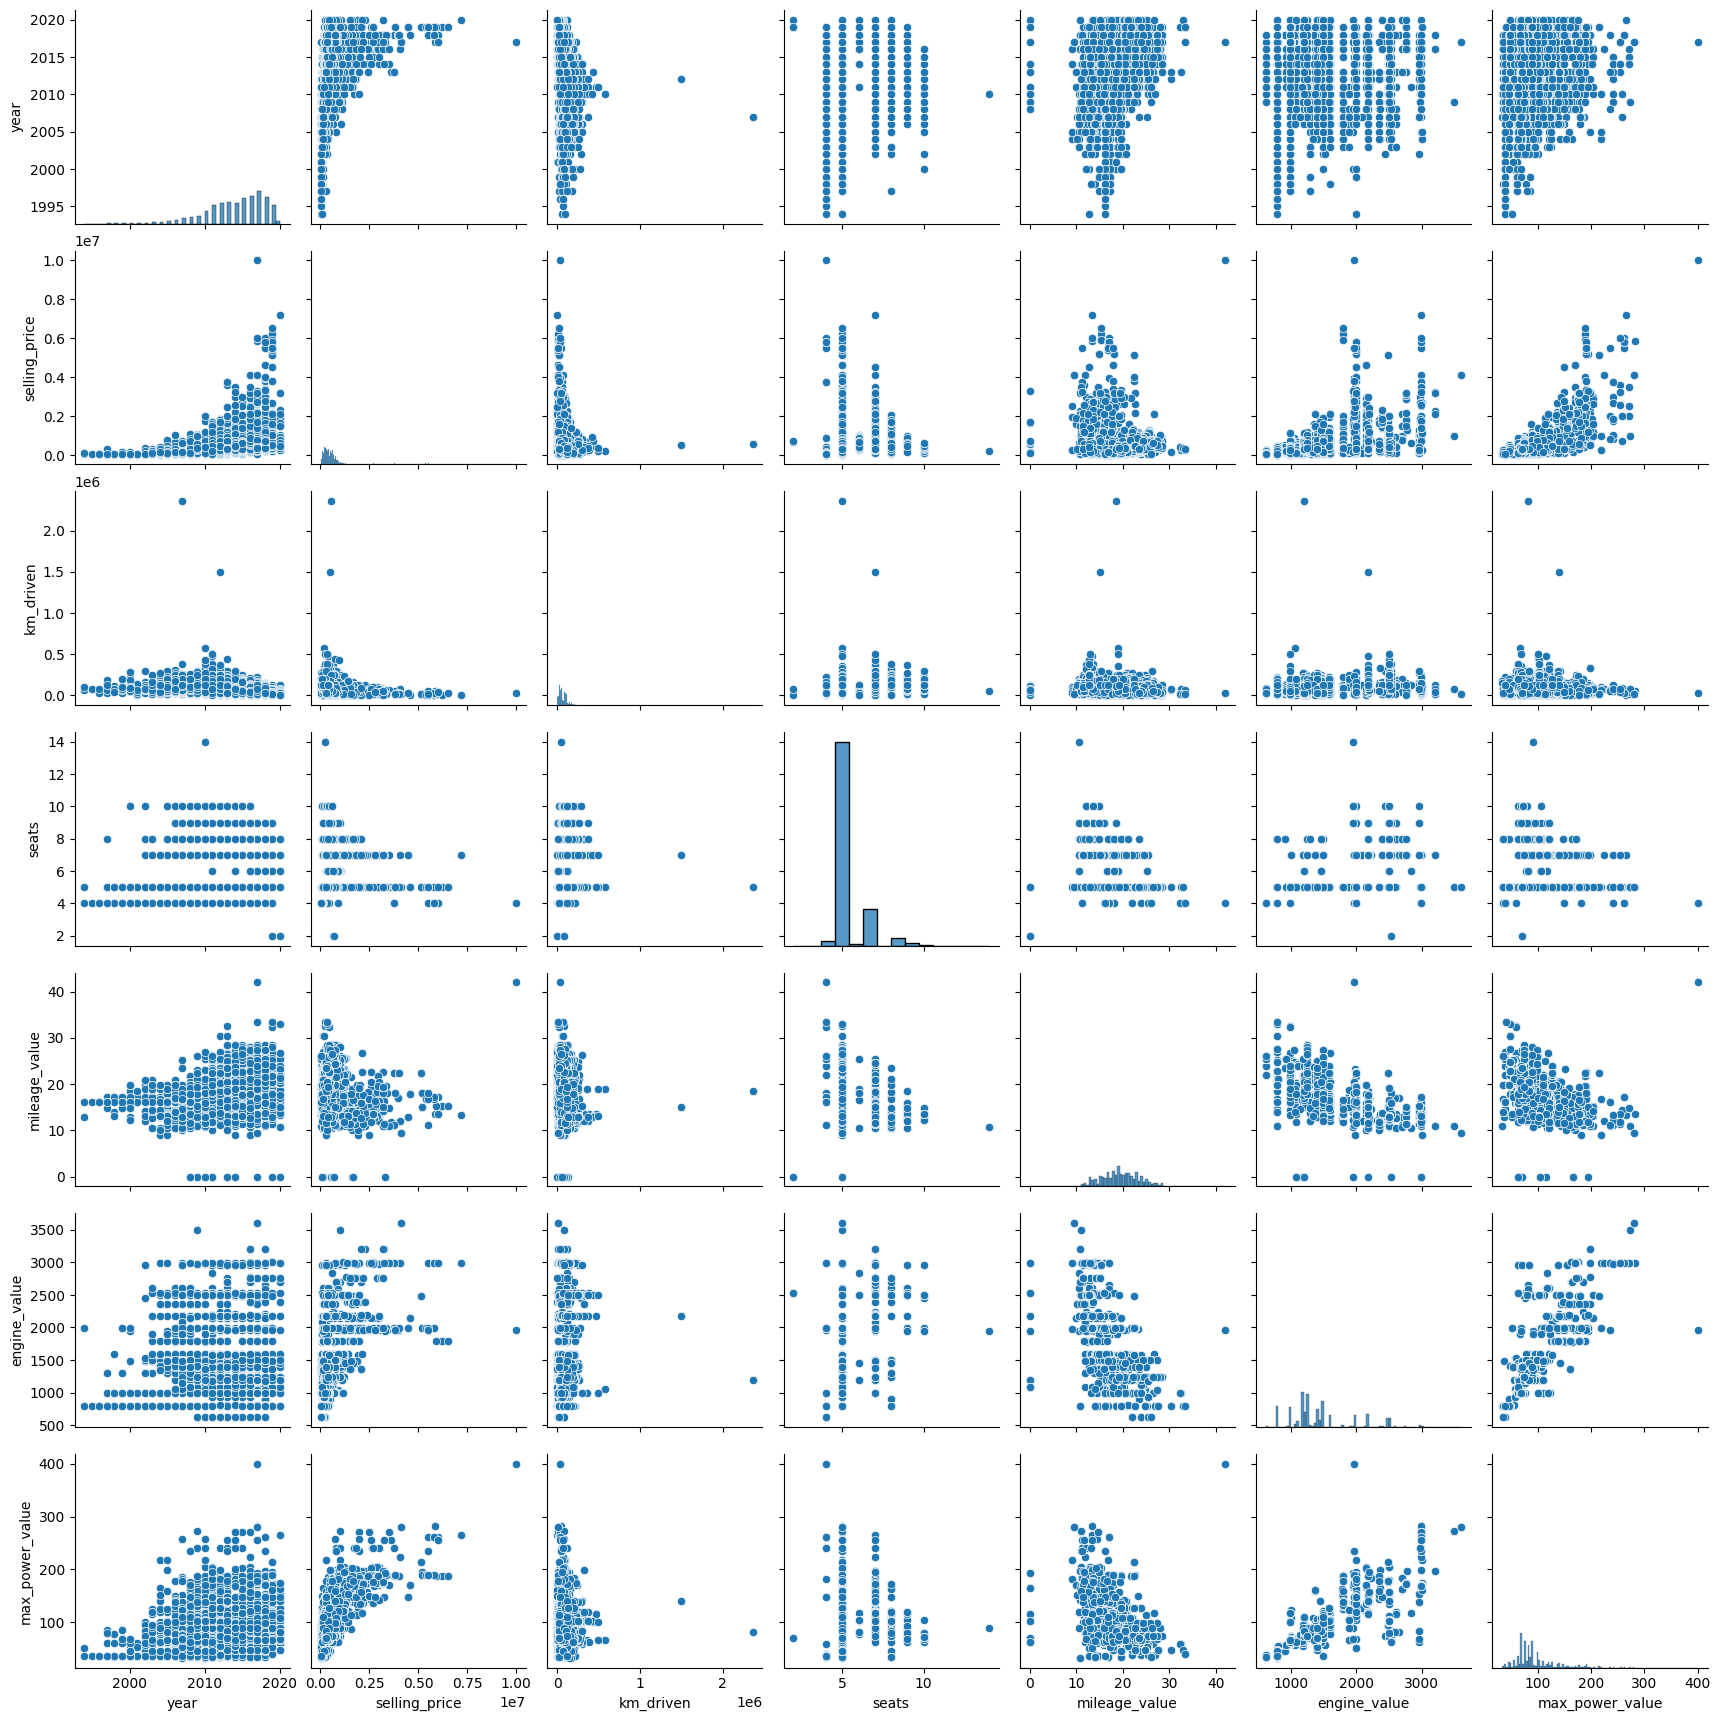

In [30]:
## distribution of all numeric columns with each other
sns.pairplot(df.select_dtypes(include='number'))


<Axes: xlabel='fuel', ylabel='count'>

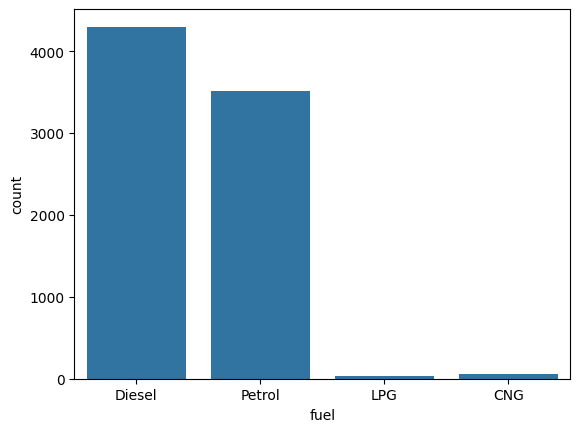

In [31]:
#distribution of categorical columns
sns.countplot(data=df, x='fuel')

([0, 1, 2, 3, 4],
 [Text(0, 0, 'First Owner'),
  Text(1, 0, 'Second Owner'),
  Text(2, 0, 'Third Owner'),
  Text(3, 0, 'Fourth & Above Owner'),
  Text(4, 0, 'Test Drive Car')])

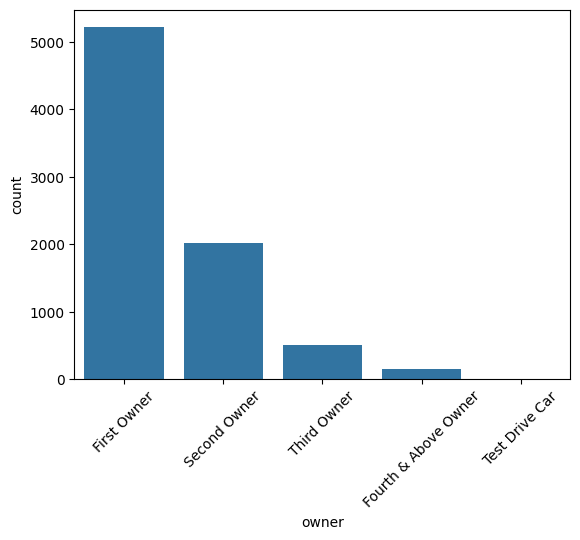

In [32]:
sns.countplot(data=df, x='owner')
plt.xticks(rotation=45)

<Axes: xlabel='transmission', ylabel='count'>

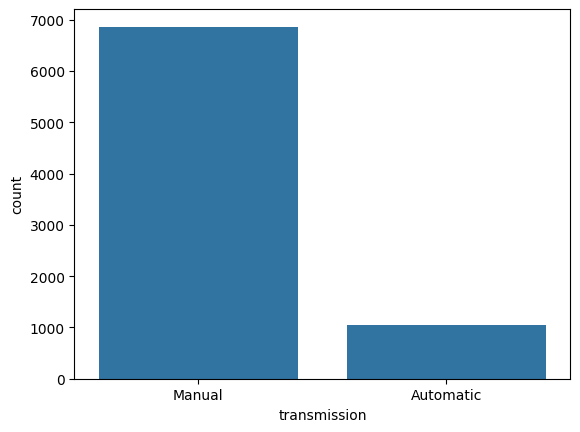

In [33]:
sns.countplot(data=df, x='transmission')

# FEATURE SELECTION


In [34]:
df['name'].nunique()

1982

In [35]:
df['brand'] = df['name'].str.split().str[0]

C:\Users\DELL\AppData\Local\Temp\ipykernel_22048\869352588.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['brand'] = df['name'].str.split().str[0]


In [36]:
df['brand'].nunique()

31

In [37]:
df['brand'].value_counts()

brand
Maruti           2367
Hyundai          1360
Mahindra          758
Tata              719
Honda             466
Toyota            452
Ford              388
Chevrolet         230
Renault           228
Volkswagen        185
BMW               118
Skoda             104
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               41
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Land                6
Force               6
Isuzu               5
Ambassador          4
Kia                 4
MG                  3
Daewoo              3
Ashok               1
Opel                1
Name: count, dtype: int64

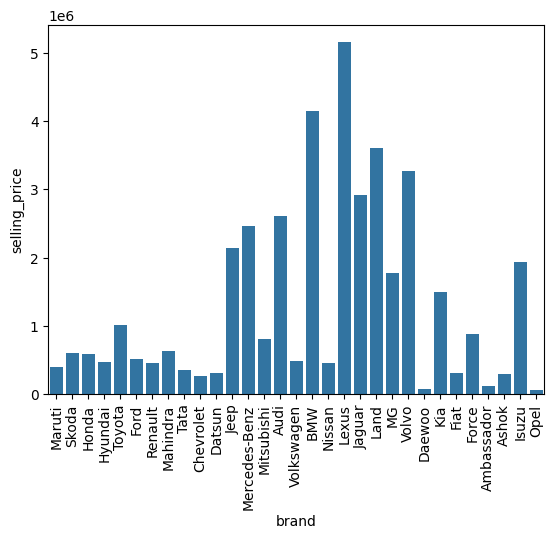

In [38]:
sns.barplot(data=df, x='brand', y='selling_price',errorbar=None)
plt.xticks(rotation=90)
plt.show()

In [39]:
df.head(2)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,mileage_value,mileage_unit,engine_value,max_power_value,brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0,23.40,kmpl,1248.0,74.00,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0,21.14,kmpl,1498.0,103.52,Skoda


In [40]:
X = df.drop(['selling_price', 'name', 'mileage', 'engine', 'max_power'],axis=1)
y = df['selling_price']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## PREPROCESSING/PIPELINE(MODEL TRAINING)

In [42]:
categorical_cols = [
    'brand',
    'fuel',
    'seller_type',
    'transmission',
    'owner',
    'mileage_unit'
]

numerical_cols = [
    'year',
    'km_driven',
    'seats',
    'mileage_value',
    'engine_value',
    'max_power_value'
]

In [43]:
trf1 = ColumnTransformer(
    transformers=[
        ('encoded_cat',OneHotEncoder(sparse_output=False, handle_unknown='ignore'),categorical_cols),
        ('scale',MinMaxScaler(),numerical_cols), 
    ],remainder='passthrough',)

# Logistic Regression Pipeline
trf2 = LinearRegression()
pipe = Pipeline([
    ('trf1', trf1), 
    ('trf2', trf2)
    ])
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('trf1', ...), ('trf2', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['year','km_driven','fuel',...,'engine_value','max_power_value','brand']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoded_cat', ...), ('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colum

In [44]:
y_pred = pipe.predict(X_test)

In [45]:
pipe.score(X_test,y_test)

0.8778200916045533

In [46]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 159859.97115710378
RMSE: 291461.17786558974
R² Score: 0.8778200916045533


In [47]:
user_data = pd.DataFrame({
    'brand': ['Maruti'],
    'year': [2014],
    'km_driven': [145500],
    'fuel': ['Diesel'],
    'seller_type': ['Individual'],
    'transmission': ['Manual'],
    'owner': ['First Owner'],
    'seats': [5.0],
    'mileage_value': [23.40],
    'mileage_unit': ['kmpl'],
    'engine_value': [1248.0],
    'max_power_value': [74.00]
})

predicted_price = pipe.predict(user_data)

print(f"Predicted Selling Price: ₹{predicted_price[0]:,.2f}")

Predicted Selling Price: ₹450,509.76


## RIDGE CLASSIFIER

In [48]:
trf3 = ColumnTransformer(
    transformers=[
        ('encoded_cat',OneHotEncoder(sparse_output=False, handle_unknown='ignore'),categorical_cols),
        ('scale',MinMaxScaler(),numerical_cols), 
    ],remainder='passthrough',)

# Logistic Regression Pipeline
trf4 = Ridge(alpha=1)
pipe_ridge = Pipeline([
    ('trf3', trf3), 
    ('trf4', trf4)
    ])
pipe_ridge.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('trf3', ...), ('trf4', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['year','km_driven','fuel',...,'engine_value','max_power_value','brand']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoded_cat', ...), ('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colum

In [49]:
y_pred_ridge = pipe_ridge.predict(X_test)

In [50]:
pipe_ridge.score(X_test,y_test)

0.8808253816174685

In [51]:
mae = mean_absolute_error(y_test, y_pred_ridge)
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ridge)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 160749.14897275
MSE: 82860091024.8952
RMSE: 287854.2878348266
R² Score: 0.8808253816174685


In [52]:
user_data = pd.DataFrame({
    'brand': ['Maruti'],
    'year': [2014],
    'km_driven': [145500],
    'fuel': ['Diesel'],
    'seller_type': ['Individual'],
    'transmission': ['Manual'],
    'owner': ['First Owner'],
    'seats': [5.0],
    'mileage_value': [23.40],
    'mileage_unit': ['kmpl'],
    'engine_value': [1248.0],
    'max_power_value': [74.00]
})

predicted_price = pipe_ridge.predict(user_data)

print(f"Predicted Selling Price: ₹{predicted_price[0]:,.2f}")

Predicted Selling Price: ₹459,148.41


In [91]:
pickle.dump(pipe_ridge, open('model.pkl', 'wb'))

### Checking assumption of linear regression

In [55]:
## 1.Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_data = X_train.select_dtypes(include='number')

vif = pd.DataFrame()
vif['Feature'] = numeric_data.columns
vif['VIF'] = [
    variance_inflation_factor(numeric_data.values, i)
    for i in range(numeric_data.shape[1])
]

print(vif)


           Feature         VIF
0             year  122.267676
1        km_driven    3.232334
2            seats   66.255375
3    mileage_value   36.851298
4     engine_value   40.329175
5  max_power_value   19.465852


Text(0.5, 1.0, 'Ridge Regression Residuals')

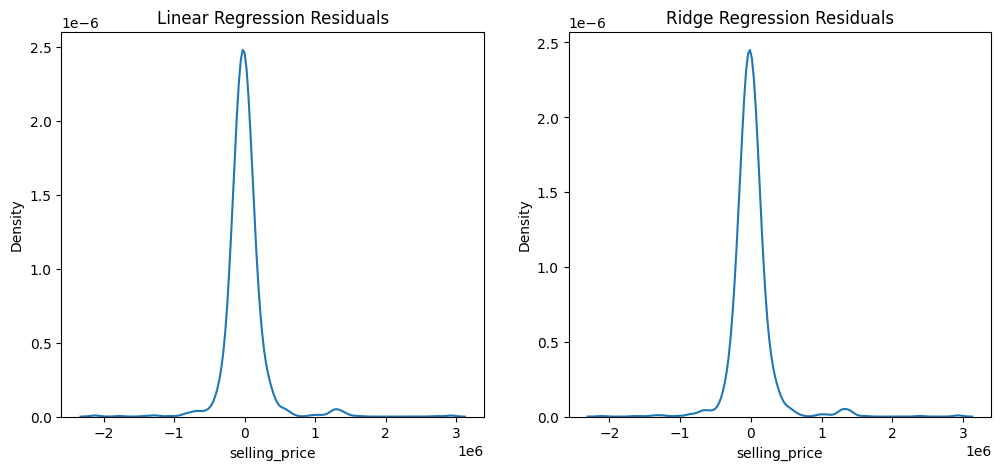

In [ ]:
## 2.Normality of residual in LR and Ridge
residual = y_test-y_pred
residual_ridge = y_test-y_pred_ridge
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(residual, ax=axes[0])
axes[0].set_title("Linear Regression Residuals")
sns.kdeplot(residual_ridge, ax=axes[1])
axes[1].set_title("Ridge Regression Residuals")

Text(0, 0.5, 'residual')

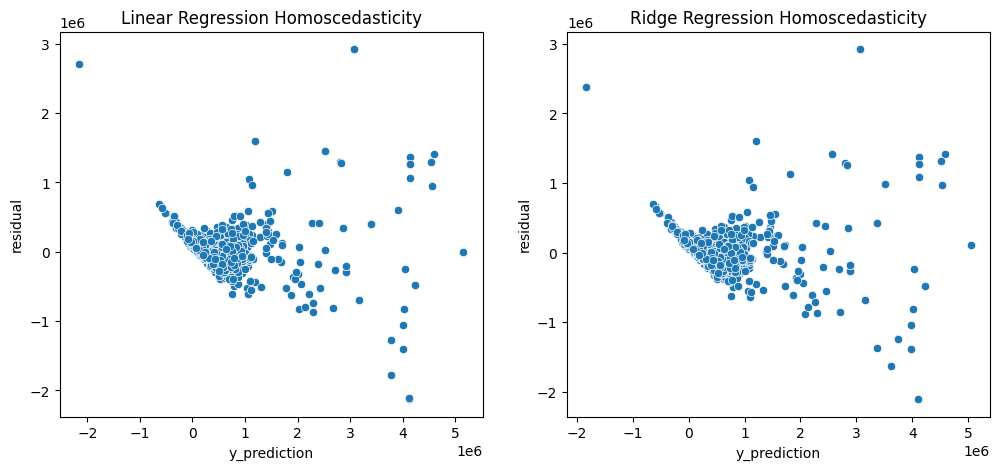

In [66]:
 ## 3.Homoscedasticity
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x=y_pred,y=residual, ax=axes[0])
axes[0].set_title("Linear Regression Homoscedasticity")
axes[0].set_xlabel('y_prediction')
axes[0].set_ylabel('residual')
sns.scatterplot(x=y_pred_ridge,y=residual_ridge, ax=axes[1])
axes[1].set_title("Ridge Regression Homoscedasticity")
axes[1].set_xlabel('y_prediction')
axes[1].set_ylabel('residual')


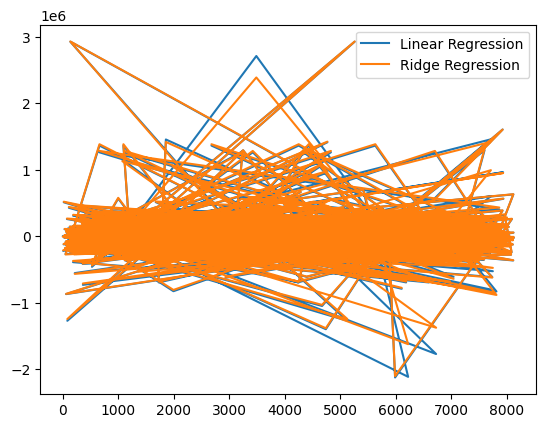

In [70]:
## 4.Autoco-relation
plt.plot(residual, label='Linear Regression')
plt.plot(residual_ridge, label='Ridge Regression')

plt.legend()
plt.show()

In [90]:
df['max_power_value'].describe()

count    7906.000000
mean       91.587374
std        35.747216
min        32.800000
25%        68.050000
50%        82.000000
75%       102.000000
max       400.000000
Name: max_power_value, dtype: float64